In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

## 📊 Descripción de variables

El dataset contiene información sobre hábitos musicales y salud mental de los participantes.

### 🧍 Datos generales
- **Age:** Edad del participante.
- **Primary streaming service:** Plataforma principal donde escucha música (Spotify, YouTube Music, etc.).
- **Hours per day:** Número de horas que escucha música al día.
- **While working:** Indica si escucha música mientras trabaja (Yes/No).

### 🎼 Relación con la música
- **Instrumentalist:** Si toca algún instrumento musical.
- **Composer:** Si compone música.
- **Fav genre:** Género musical favorito.
- **Exploratory:** Si le gusta explorar nueva música.
- **Foreign languages:** Si escucha música en otros idiomas.
- **BPM:** Ritmo de la música (beats per minute).

### 🎧 Frecuencia por género
Indican qué tan seguido escucha cada género:
- Frequency [Classical]
- Frequency [Country]
- Frequency [EDM]
- Frequency [Folk]
- Frequency [Gospel]
- Frequency [Hip hop]
- Frequency [Jazz]
- Frequency [K pop]
- Frequency [Latin]
- Frequency [Lofi]
- Frequency [Metal]
- Frequency [Pop]
- Frequency [R&B]
- Frequency [Rap]
- Frequency [Rock]
- Frequency [Video game music]

Los valores representan:
- Never (Nunca)
- Rarely (Rara vez)
- Sometimes (A veces)
- Very frequently (Muy frecuentemente)

### 🧠 Salud mental
- **Anxiety:** Nivel de ansiedad (escala numérica).
- **Depression:** Nivel de depresión.
- **Insomnia:** Nivel de insomnio.
- **OCD:** Nivel de trastorno obsesivo-compulsivo.

### 🎵 Percepción de la música
- **Music effects:** Efecto percibido de la música (Improve, No effect, etc.).

In [2]:
df = pd.read_csv("mxmh_survey_results.csv")
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [3]:
df.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [4]:
df.isnull().sum()

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

In [5]:
# Copia de seguridad
df_clean = df.copy()

# Eliminar columnas poco útiles
df_clean = df_clean.drop(columns=["Timestamp", "Permissions"], errors='ignore')

# Convertir numéricas
cols_numeric = ["Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD"]

for col in cols_numeric:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Manejo de nulos

# BPM -> demasiados nulos → eliminar columna
df_clean = df_clean.drop(columns=["BPM"])

# Rellenar categóricas con "Unknown"
cols_cat = df_clean.select_dtypes(include="str").columns
df_clean[cols_cat] = df_clean[cols_cat].fillna("Unknown")

# Eliminar filas con valores críticos nulos
df_clean = df_clean.dropna(subset=["Age", "Hours per day"])

df_clean.isnull().sum()

Age                             0
Primary streaming service       0
Hours per day                   0
While working                   0
Instrumentalist                 0
Composer                        0
Fav genre                       0
Exploratory                     0
Foreign languages               0
Frequency [Classical]           0
Frequency [Country]             0
Frequency [EDM]                 0
Frequency [Folk]                0
Frequency [Gospel]              0
Frequency [Hip hop]             0
Frequency [Jazz]                0
Frequency [K pop]               0
Frequency [Latin]               0
Frequency [Lofi]                0
Frequency [Metal]               0
Frequency [Pop]                 0
Frequency [R&B]                 0
Frequency [Rap]                 0
Frequency [Rock]                0
Frequency [Video game music]    0
Anxiety                         0
Depression                      0
Insomnia                        0
OCD                             0
Music effects 

### Distribución de ansiedad, depresión, insomnio y OCD

Se observa cómo se distribuyen los valores de las variables de salud mental.

En general:
- La mayoría de los valores se concentran en niveles bajos a medios.
- Existen algunos valores altos, lo que indica que ciertos participantes presentan niveles elevados de estas condiciones.
- Esto sugiere que la muestra incluye tanto personas con bajo como alto nivel de afectación emocional.

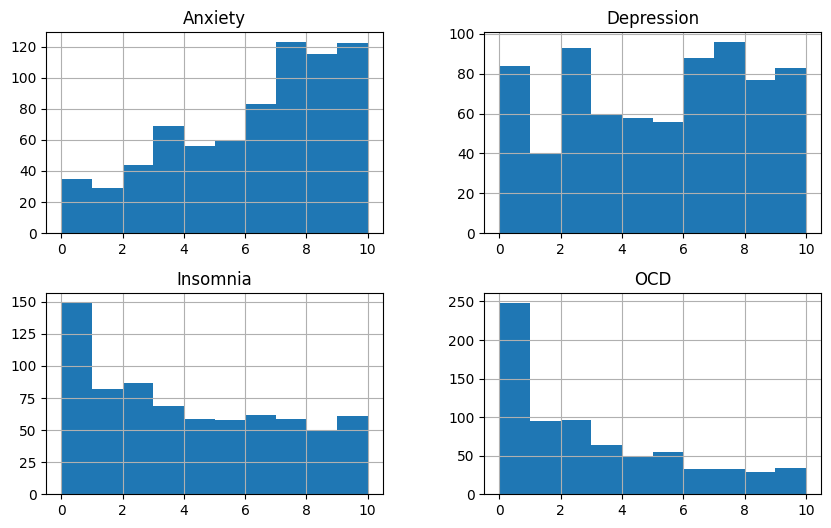

In [6]:
mental_cols = ["Anxiety", "Depression", "Insomnia", "OCD"]

df_clean[mental_cols].hist(figsize=(10,6))
plt.show()

### Detección de valores atípicos (outliers)

El boxplot muestra la distribución de la edad y las horas de consumo de música.

Se observa que:
- Existen valores extremos en las horas de escucha, lo que indica que algunos usuarios escuchan música durante muchas horas al día.
- La edad presenta menor variabilidad, aunque puede haber algunos valores fuera de lo común.

Esto es importante ya que los outliers pueden influir en los resultados del análisis.

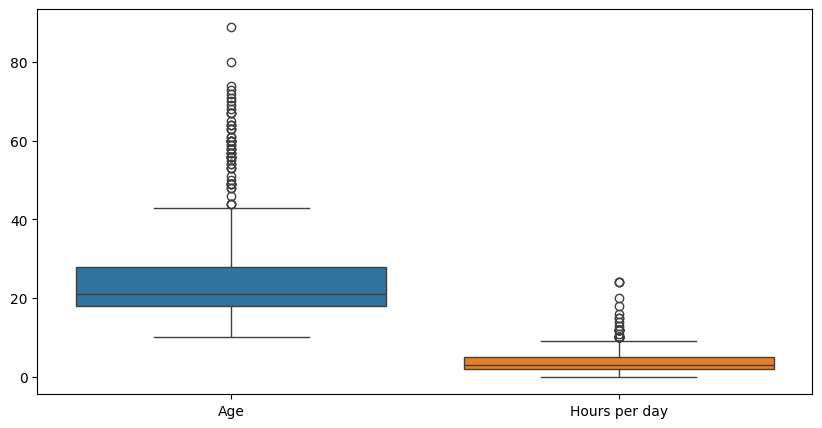

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[["Age", "Hours per day"]])
plt.show()

### Plataforma de streaming más utilizada

Se observa la frecuencia de uso de cada servicio de música.

Los resultados muestran que:
- Algunas plataformas dominan claramente (como Spotify o YouTube).
- Esto indica una preferencia fuerte por ciertos servicios dentro de la muestra.

Este dato puede ser relevante si el tipo de plataforma influye en los hábitos musicales.

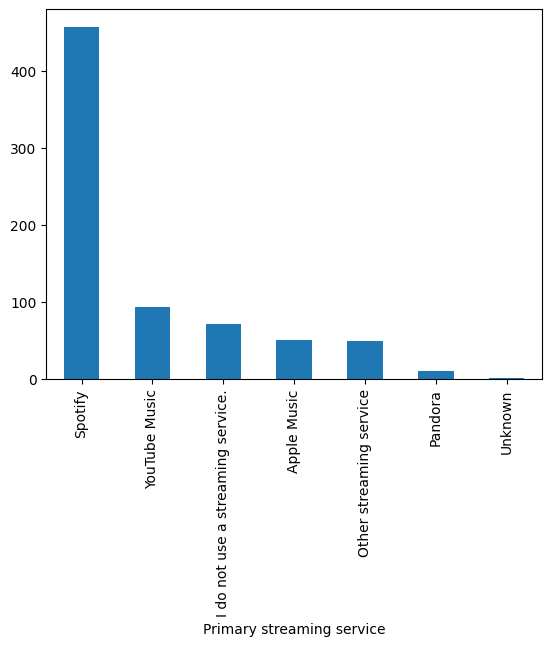

In [8]:
plt.figure()
df_clean["Primary streaming service"].value_counts().plot(kind="bar")
plt.show()

### Relación entre horas de música y salud mental

Las gráficas de dispersión permiten observar la relación entre el tiempo de escucha y variables como ansiedad o depresión.

Se observa que:
- No existe una relación completamente lineal.
- Sin embargo, algunos usuarios con mayor consumo presentan niveles elevados de ansiedad o depresión.

Esto sugiere que el tiempo de escucha podría estar relacionado con el estado emocional, aunque no es el único factor.

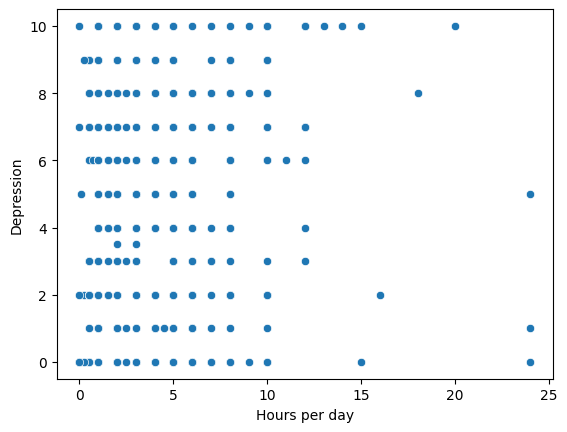

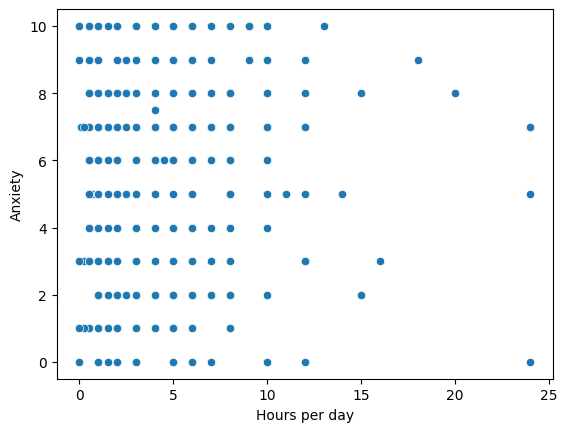

In [9]:
sns.scatterplot(x="Hours per day", y="Depression", data=df_clean)
plt.show()

sns.scatterplot(x="Hours per day", y="Anxiety", data=df_clean)
plt.show()

### Relación entre género musical y ansiedad

El boxplot muestra cómo varía la ansiedad según el género musical favorito.

Se observa que:
- Algunos géneros presentan mayor variabilidad en los niveles de ansiedad.
- Otros géneros tienen valores más concentrados.

Esto sugiere que el tipo de música podría estar asociado con diferentes estados emocionales.

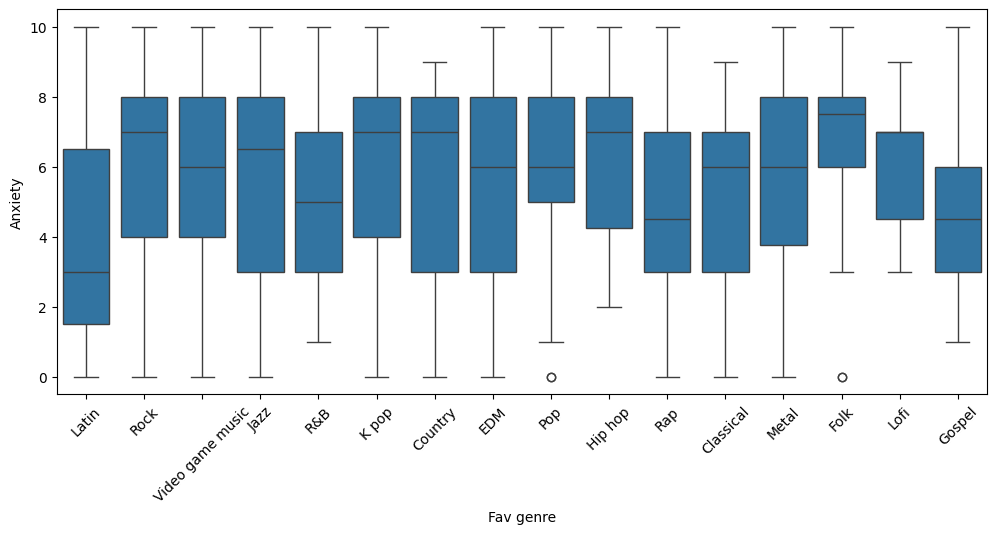

In [10]:
plt.figure(figsize=(12,5))
sns.boxplot(x="Fav genre", y="Anxiety", data=df_clean)
plt.xticks(rotation=45)
plt.show()

### Correlación entre variables

La matriz de correlación muestra la relación entre variables numéricas.

Se observa que:
- Existe una fuerte relación entre ansiedad y depresión.
- Algunas variables presentan correlaciones moderadas.
- Las horas de música tienen una relación débil con las variables mentales.

Esto indica que la salud mental está más relacionada entre sí que con el consumo de música directamente.

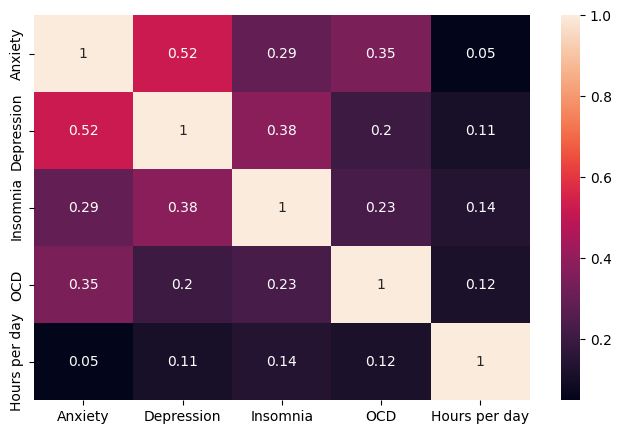

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[mental_cols + ["Hours per day"]].corr(), annot=True)
plt.show()

### Géneros musicales más populares

La gráfica muestra los géneros favoritos de los participantes.

Se observa que:
- Algunos géneros destacan sobre otros, lo que refleja tendencias musicales claras.
- Esto puede influir en la relación con la salud mental, ya que diferentes géneros pueden generar distintas emociones.

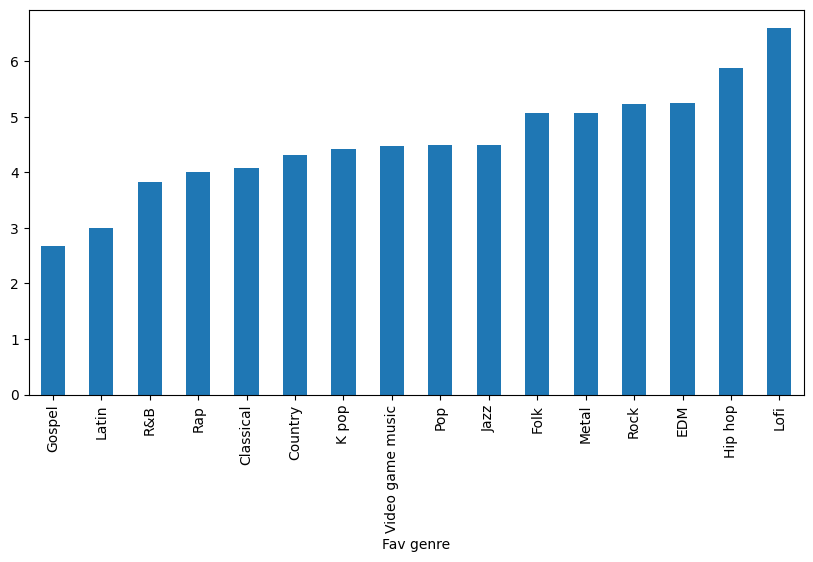

In [12]:
df_clean.groupby("Fav genre")["Depression"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.show()

### Efecto de la música en la ansiedad

Se observa cómo cambia la ansiedad según el efecto percibido de la música.

Se identifica que:
- Las personas que indican que la música mejora su estado presentan ciertos patrones.
- Aquellos que no perciben efecto pueden tener niveles distintos.

Esto sugiere que la percepción personal de la música es importante.

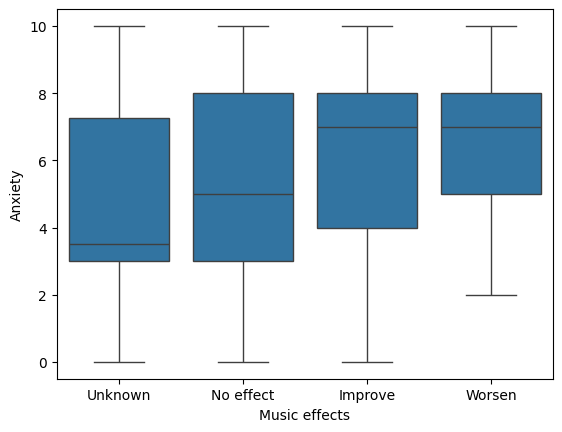

In [13]:
sns.boxplot(x="Music effects", y="Anxiety", data=df_clean)
plt.show()

### Escuchar música mientras se trabaja

Se analiza la ansiedad en función de si la persona escucha música mientras trabaja.

Se observa que:
- Puede haber diferencias entre quienes escuchan música y quienes no.
- Esto podría indicar que la música influye en la concentración o el estado emocional durante el trabajo.

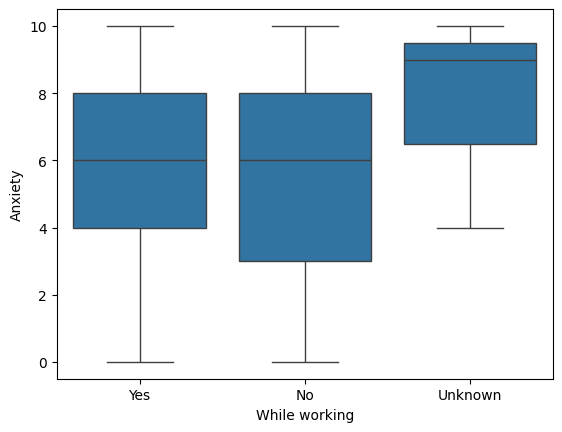

In [14]:
sns.boxplot(x="While working", y="Anxiety", data=df_clean)
plt.show()

In [15]:
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

freq_cols = [col for col in df_clean.columns if "Frequency" in col]

for col in freq_cols:
    df_clean[col] = df_clean[col].map(freq_map)

### Relación entre frecuencia de géneros y salud mental

Se observa la correlación entre la frecuencia de escucha de distintos géneros y variables como ansiedad o depresión.

Se identifica que:
- Algunos géneros presentan correlaciones positivas o negativas.
- Esto sugiere que ciertos estilos musicales podrían estar asociados con distintos estados emocionales.

Este análisis es clave para entender patrones más profundos en los datos.

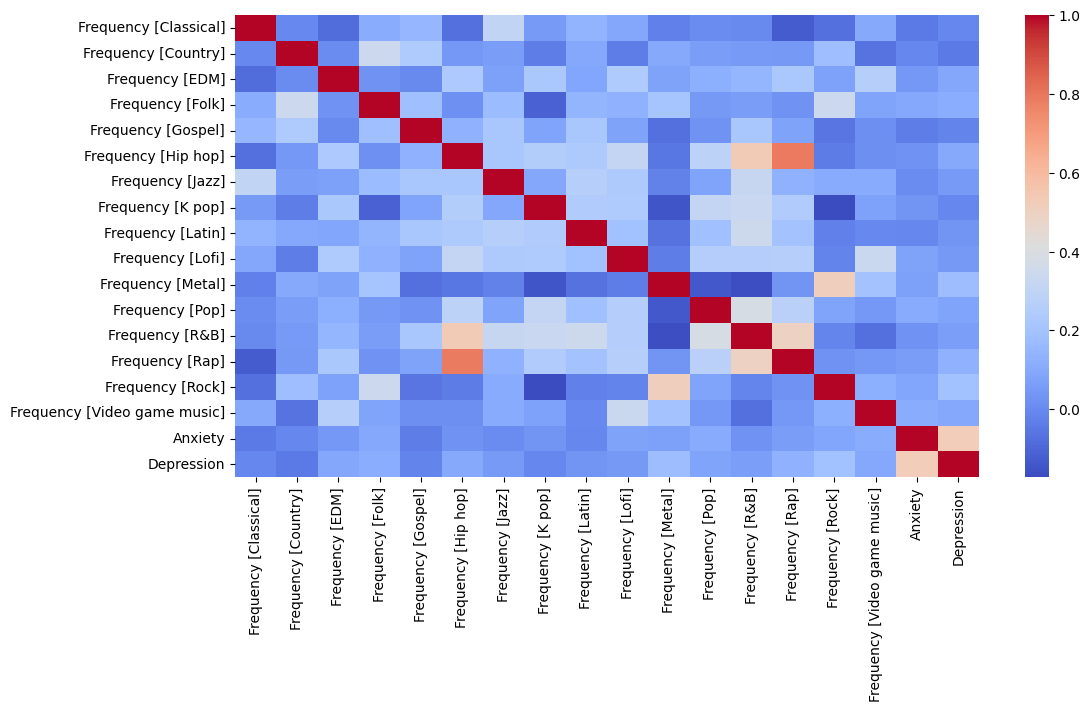

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(df_clean[freq_cols + ["Anxiety", "Depression"]].corr(), cmap="coolwarm")
plt.show()

# Fase 2 – Modelado Predictivo, Comparación y Selección de Modelos

En esta fase se construyen modelos predictivos para estimar el nivel de ansiedad a partir de hábitos musicales y características personales. Se parte del dataset limpio producido en la Fase 1 y se aplica un flujo riguroso de preprocesamiento, entrenamiento, ajuste de hiperparámetros y evaluación comparativa.

## Importaciones para la Fase 2

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42

## Definición del problema

El objetivo de este proyecto es **predecir el nivel de ansiedad** de un individuo (escala de 0 a 10) a partir de sus hábitos de consumo musical y características personales.

Este es un **problema de regresión** porque la variable objetivo (`Anxiety`) es numérica y continua.  
No se busca establecer causalidad, sino identificar patrones predictivos que permitan estimar el nivel de ansiedad dado un perfil musical.

## Preprocesamiento de datos

### Decisiones tomadas con base en el EDA (Fase 1)

| Variable | Acción | Justificación |
|---|---|---|
| `Timestamp`, `Permissions` | Eliminadas en Fase 1 | Sin valor predictivo |
| `BPM` | Eliminada | 107 nulos (~15%) y distribución extremamente sesgada (máx. 1×10⁹); no aporta señal confiable |
| `Age`, `Hours per day` | Filas con nulos eliminadas | Solo 1-2 registros afectados; perder pocas filas es preferible a imputar variables clave |
| Variables categóricas con nulos | Imputadas con `"Unknown"` | Preserva la información de que el dato no fue reportado |
| `Hours per day > 10` | Filas eliminadas | Valores >10 h/día son outliers de captura; biológicamente improbables como práctica diaria sostenida |
| Frecuencias ordinales | Ordinal Encoding (`Never=0, Rarely=1, Sometimes=2, Very frequently=3`) | Las frecuencias tienen un orden intrínseco; OHE crearía columnas redundantes y perdería el orden natural |
| Variables Yes/No binarias | Binario (Yes=1, No=0) | Codificación directa y eficiente |
| `Fav genre`, `Primary streaming service`, `Music effects` | One-Hot Encoding | Variables nominales sin orden natural |

### Feature engineering (antes del split)

Se crean tres variables derivadas **antes de definir X e Y**, para asegurar que entren al modelo:

- `total_music_freq`: suma de todas las frecuencias → intensidad total de consumo musical
- `genre_diversity`: número de géneros con frecuencia > 0 → amplitud de gustos musicales  
- `avg_music_freq`: promedio de frecuencias → nivel promedio de escucha por género

In [18]:
# ── Partir del df_clean producido en Fase 1 ──────────────────────────────────
df_model = df_clean[df_clean["Hours per day"] <= 10].copy()

# ── Ordinal Encoding para frecuencias ────────────────────────────────────────
freq_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}
freq_cols = [col for col in df_model.columns if "Frequency" in col]
df_model[freq_cols] = df_model[freq_cols].replace(freq_map)

# ── Feature engineering ANTES de definir X e y ───────────────────────────────
df_model["total_music_freq"] = df_model[freq_cols].sum(axis=1)
df_model["genre_diversity"]  = (df_model[freq_cols] > 0).sum(axis=1)
df_model["avg_music_freq"]   = df_model[freq_cols].mean(axis=1)

# ── Binarias Yes/No ───────────────────────────────────────────────────────────
binary_cols = ["While working", "Instrumentalist", "Composer", "Exploratory", "Foreign languages"]
for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0, "Unknown": 0})

# ── One-Hot Encoding para nominales ──────────────────────────────────────────
df_model = pd.get_dummies(df_model, columns=["Fav genre", "Primary streaming service", "Music effects"], drop_first=True)

# ── Limpiar nombres de columnas (XGBoost no acepta brackets) ─────────────────
df_model.columns = [c.replace("[","").replace("]","").replace("<","").replace(" ","_") for c in df_model.columns]

print(f"Shape final: {df_model.shape}")
print(f"Nulos restantes: {df_model.isnull().sum().sum()}")
df_model.head(3)

Shape final: (715, 54)
Nulos restantes: 0


,Age,Hours_per_day,While_working,Instrumentalist,Composer,Exploratory,Foreign_languages,Frequency_Classical,Frequency_Country,Frequency_EDM,...,Fav_genre_Video_game_music,Primary_streaming_service_I_do_not_use_a_streaming_service.,Primary_streaming_service_Other_streaming_service,Primary_streaming_service_Pandora,Primary_streaming_service_Spotify,Primary_streaming_service_Unknown,Primary_streaming_service_YouTube_Music,Music_effects_No_effect,Music_effects_Unknown,Music_effects_Worsen
0,18.0,3.0,1,1,1,1,1,1,0,1,...,False,False,False,False,True,False,False,False,True,False
1,63.0,1.5,1,0,0,1,0,2,0,0,...,False,False,False,True,False,False,False,False,True,False
2,18.0,4.0,0,0,0,0,1,0,0,3,...,True,False,False,False,True,False,False,True,False,False


## División entrenamiento / prueba

Se utiliza una división **80% / 20%** con `random_state=42`.  
Con ~700 registros, esta proporción deja ~560 para entrenamiento (suficiente para GridSearchCV con cv=5) y ~140 para prueba (suficiente para métricas estables).  
El `random_state` fijo garantiza reproducibilidad total.

In [19]:
X = df_model.drop("Anxiety", axis=1)
y = df_model["Anxiety"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (572, 53) | Test: (143, 53)


## Imputación y escalado

**Imputación:** Se aplica `SimpleImputer(strategy="median")` sobre el conjunto de entrenamiento y se aplica el mismo transformador al de prueba. Se usa la mediana porque las variables numéricas (`Age`, `Hours per day`) tienen distribuciones sesgadas.

**Escalado:** Se crea `X_train_scaled` / `X_test_scaled` para la Regresión Lineal, que es sensible a la escala. Random Forest y XGBoost son invariantes a la escala, por lo que se entrenan con los datos sin escalar (`X_train` / `X_test`). El escalado se hace **después del split** para evitar data leakage.

In [20]:
# ── Imputación ───────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# ── Escalado para Regresión Lineal ────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print("Imputación y escalado completados.")
print(f"X_train nulos: {X_train.isnull().sum().sum()} | X_test nulos: {X_test.isnull().sum().sum()}")

Imputación y escalado completados.
X_train nulos: 0 | X_test nulos: 0


In [21]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — evita división por cero omitiendo y_true == 0"""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluar_modelo(nombre, y_true, y_pred, y_train_true, y_train_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape_val = mape(y_true.values, y_pred)
    r2_train = r2_score(y_train_true, y_train_pred)
    print(f"{'='*45}")
    print(f"  {nombre}")
    print(f"  RMSE  : {rmse:.4f}  (error promedio en unidades de Anxiety)")
    print(f"  MAE   : {mae:.4f}")
    print(f"  R²    : {r2:.4f}  (train R²: {r2_train:.4f})")
    print(f"  MAPE  : {mape_val:.2f}%")
    return {"Modelo": nombre, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE (%)": mape_val, "R2_train": r2_train}

## Modelo 1: Regresión Lineal

### Descripción conceptual
La Regresión Lineal asume que la variable objetivo puede expresarse como una combinación lineal ponderada de las variables predictoras: **ŷ = β₀ + β₁x₁ + … + βₙxₙ**. El modelo minimiza la suma de errores cuadráticos (OLS) para encontrar los coeficientes óptimos.

### Justificación de uso en este problema
Se incluye como **línea base** porque es altamente interpretable: sus coeficientes indican directamente cuánto aumenta la ansiedad predicha por cada unidad de cambio en una variable. Además, como los datos contienen tanto variables ordinales como one-hot encoded, la regresión lineal puede capturar efectos aditivos simples. Se espera que no capture relaciones no lineales, pero su rendimiento sirve de referencia mínima.

La Regresión Lineal es sensible a la escala, por lo que se entrena con `X_train_scaled`.

In [22]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr       = model_lr.predict(X_test_scaled)
y_pred_lr_train = model_lr.predict(X_train_scaled)

metrics_lr = evaluar_modelo("Regresión Lineal", y_test, y_pred_lr, y_train, y_pred_lr_train)

  Regresión Lineal
  RMSE  : 2.3380  (error promedio en unidades de Anxiety)
  MAE   : 1.8631
  R²    : 0.2974  (train R²: 0.4142)
  MAPE  : 44.10%


In [23]:
cv_lr = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring="r2")
print(f"Cross-validation R² (Regresión Lineal): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

Cross-validation R² (Regresión Lineal): 0.2533 ± 0.1183


## Modelo 2: Random Forest

### Descripción conceptual
Random Forest es un método de ensamble que entrena múltiples Árboles de Decisión en subconjuntos aleatorios del dataset (bagging) y promedia sus predicciones. Cada árbol ve una muestra aleatoria de filas *y* de variables en cada nodo, lo que reduce la correlación entre árboles y mejora la generalización frente a un árbol único.

### Justificación de uso en este problema
El dataset contiene variables ordinales, binarias y categóricas codificadas, con relaciones probablemente no lineales (confirmado por el EDA: correlaciones débiles y distribuciones asimétricas). Random Forest captura estas relaciones sin requerir supuestos de linealidad ni normalidad. Además, provee importancia de variables de forma nativa, que es clave para la interpretación del dominio.

### Hiperparámetros explorados
Se usa `GridSearchCV` con `cv=5` sobre:
- `n_estimators`: cantidad de árboles [100, 200, 300]
- `max_depth`: profundidad máxima [None, 10, 20] — controla el overfitting
- `min_samples_split`: mínimo de muestras para dividir un nodo [2, 5] — regularización adicional

In [24]:
param_grid_rf = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

print(f"Mejores hiperparámetros RF: {grid_rf.best_params_}")
print(f"Mejor R² en CV (GridSearch): {grid_rf.best_score_:.4f}")
best_rf = grid_rf.best_estimator_

Mejores hiperparámetros RF: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Mejor R² en CV (GridSearch): 0.3199


In [25]:
cv_rf = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2")
print(f"Cross-validation R² (Random Forest): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

y_pred_rf       = best_rf.predict(X_test)
y_pred_rf_train = best_rf.predict(X_train)

metrics_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf, y_train, y_pred_rf_train)

Cross-validation R² (Random Forest): 0.3199 ± 0.0434
  Random Forest
  RMSE  : 2.2630  (error promedio en unidades de Anxiety)
  MAE   : 1.8191
  R²    : 0.3418  (train R²: 0.8724)
  MAPE  : 42.61%


## Modelo 3 (Puntos Extra): XGBoost

### Descripción conceptual
XGBoost (*eXtreme Gradient Boosting*) es un método de boosting que construye árboles de forma **secuencial**: cada árbol nuevo corrige los residuos del conjunto anterior, minimizando una función de pérdida mediante descenso de gradiente. A diferencia de Random Forest (que usa bagging con árboles independientes en paralelo), XGBoost aprende iterativamente, lo que le permite ajustarse mejor a patrones complejos con regularización explícita (L1/L2) para controlar el overfitting.

### ¿Qué lo hace diferente a los otros dos modelos?
- Frente a la **Regresión Lineal**: captura relaciones no lineales e interacciones entre variables sin necesidad de términos de interacción explícitos.
- Frente a **Random Forest**: usa boosting (secuencial + residuos) en lugar de bagging (paralelo + promedio), incorpora regularización L1/L2 nativa, y suele ser más eficiente con datasets pequeños/medianos.

### Hiperparámetros explorados
- `n_estimators`: número de árboles [100, 300, 500]
- `max_depth`: profundidad máxima [3, 5, 7]
- `learning_rate`: paso de actualización (shrinkage) [0.05, 0.1, 0.2]

In [26]:
param_grid_xgb = {
    "n_estimators":  [100, 300, 500],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train, y_train)

print(f"Mejores hiperparámetros XGBoost: {grid_xgb.best_params_}")
print(f"Mejor R² en CV (GridSearch): {grid_xgb.best_score_:.4f}")
best_xgb = grid_xgb.best_estimator_

Mejores hiperparámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Mejor R² en CV (GridSearch): 0.3374


In [27]:
cv_xgb = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring="r2")
print(f"Cross-validation R² (XGBoost): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

y_pred_xgb       = best_xgb.predict(X_test)
y_pred_xgb_train = best_xgb.predict(X_train)

metrics_xgb = evaluar_modelo("XGBoost", y_test, y_pred_xgb, y_train, y_pred_xgb_train)

Cross-validation R² (XGBoost): 0.3374 ± 0.0546
  XGBoost
  RMSE  : 2.3117  (error promedio en unidades de Anxiety)
  MAE   : 1.8222
  R²    : 0.3131  (train R²: 0.5916)
  MAPE  : 44.54%


## Comparación de modelos

### Métricas en el conjunto de prueba

La tabla incluye MAPE para permitir interpretación porcentual (e.g., "el modelo se equivoca en promedio X% del valor real de ansiedad") y `R²_train` para diagnosticar overfitting.

In [28]:
results = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb])
results = results.round(4)
print(results.to_string(index=False))
results

          Modelo   RMSE    MAE     R2  MAPE (%)  R2_train
Regresión Lineal 2.3380 1.8631 0.2974   44.1030    0.4142
   Random Forest 2.2630 1.8191 0.3418   42.6088    0.8724
         XGBoost 2.3117 1.8222 0.3131   44.5400    0.5916


,Modelo,RMSE,MAE,R2,MAPE (%),R2_train
0,Regresión Lineal,2.3380,1.8631,0.2974,44.1030,0.4142
1,Random Forest,2.2630,1.8191,0.3418,42.6088,0.8724
2,XGBoost,2.3117,1.8222,0.3131,44.5400,0.5916


### Gráfica comparativa de métricas

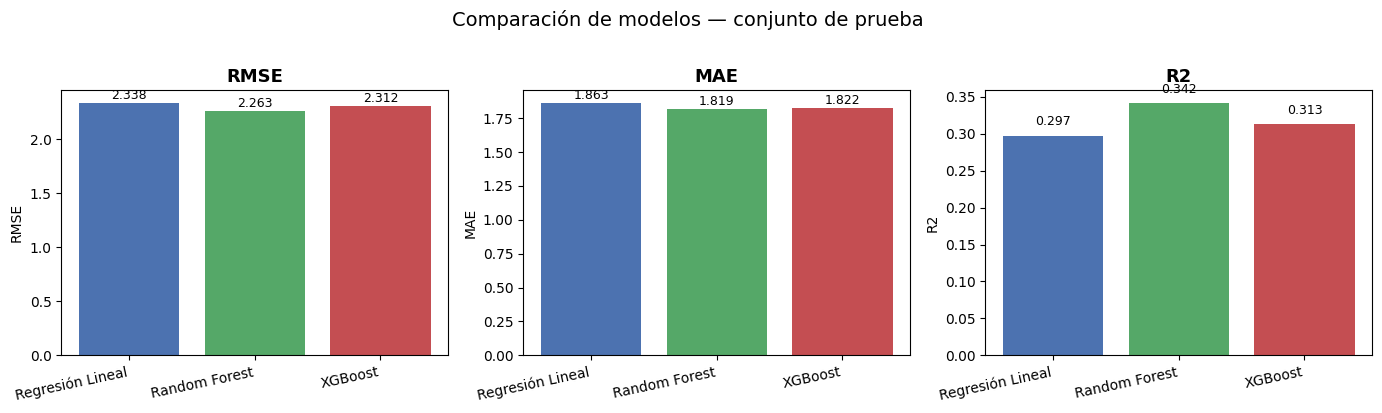

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
modelos = results["Modelo"]
colors  = ["#4C72B0", "#55A868", "#C44E52"]

for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    bars = ax.bar(modelos, results[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(modelos, rotation=12, ha="right")
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparación de modelos — conjunto de prueba", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Gráficas: Predicción vs Real (los tres modelos)

La diagonal punteada representa predicción perfecta. Cuanto más cerca estén los puntos de la diagonal, mejor el modelo.

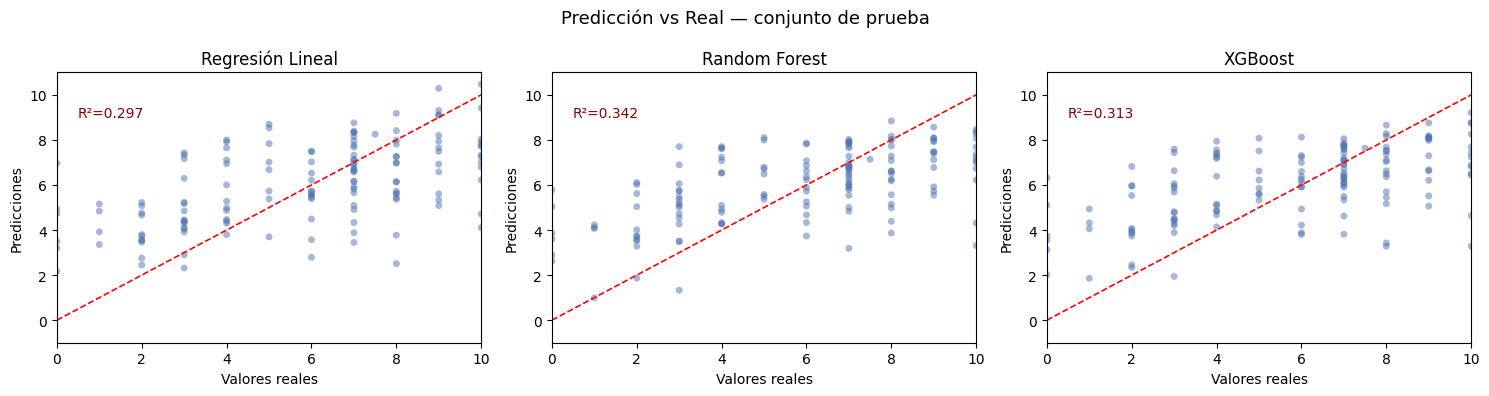

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

preds  = [y_pred_lr,        y_pred_rf,       y_pred_xgb]
titles = ["Regresión Lineal", "Random Forest", "XGBoost"]

for ax, prd, title in zip(axes, preds, titles):
    ax.scatter(y_test, prd, alpha=0.5, edgecolors="none", color="#4C72B0", s=25)
    lims = [0, 10]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfecta")
    ax.set_xlabel("Valores reales")
    ax.set_ylabel("Predicciones")
    ax.set_title(title)
    ax.set_xlim(lims); ax.set_ylim([-1, 11])
    r2_val = r2_score(y_test, prd)
    ax.text(0.5, 9, f"R²={r2_val:.3f}", fontsize=10, color="darkred")

plt.suptitle("Predicción vs Real — conjunto de prueba", fontsize=13)
plt.tight_layout()
plt.show()

## Evaluación y comparación entre modelos

Se utilizan las métricas RMSE, MAE, R², MAPE y R²_train sobre el conjunto de prueba:

| Modelo | RMSE | MAE | R² | MAPE (%) | R²_train |
|---|---|---|---|---|---|
| Regresión Lineal | 2.3380 | 1.8631 | 0.2974 | 44.10% | 0.4142 |
| Random Forest | **2.2630** | **1.8191** | **0.3418** | **42.61%** | 0.8724 |
| XGBoost | 2.3117 | 1.8222 | 0.3131 | 44.54% | 0.5916 |

**Random Forest** obtiene el menor error (RMSE 2.26) y el mayor R² (0.34), siendo el modelo ganador.

El **MAPE** se interpreta directamente: el modelo se equivoca en promedio un 42.6% del valor real de ansiedad reportado. Dado que la escala es 0–10 y los valores tienden a concentrarse entre 4 y 8, un error absoluto de ~1.8 puntos (MAE) en una escala de 10 es un resultado razonable para datos auto-reportados.

**¿Qué métrica es prioritaria aquí?** Para este dominio (predicción de bienestar mental a partir de encuestas), el **RMSE y el R²** son las métricas más relevantes: el RMSE penaliza errores grandes, que en este contexto equivalen a clasificar incorrectamente a una persona con ansiedad alta como si tuviera ansiedad baja. El MAPE es útil para comunicar el error en términos porcentuales a una audiencia no técnica.

### Distribución de residuos (Random Forest — modelo ganador)

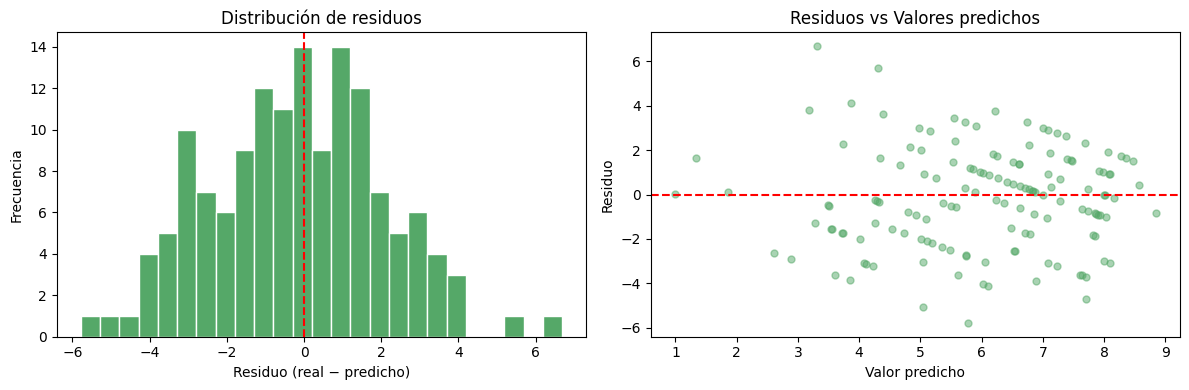

In [31]:
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=25, color="#55A868", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Residuo (real − predicho)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos")

axes[1].scatter(y_pred_rf, residuals, alpha=0.5, color="#55A868", s=25)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Valor predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos vs Valores predichos")

plt.tight_layout()
plt.show()

## Análisis de overfitting / underfitting

Se comparan los R² de entrenamiento y prueba para los tres modelos:

| Modelo | R² Train | R² Test | Gap | Diagnóstico |
|---|---|---|---|---|
| Regresión Lineal | 0.4142 | 0.2974 | 0.117 | Underfitting moderado — capacidad limitada para capturar no-linealidades |
| Random Forest | 0.8724 | 0.3418 | **0.531** | **Overfitting severo** — memoriza entrenamiento, generaliza poco |
| XGBoost | 0.5916 | 0.3131 | 0.278 | Overfitting moderado — controlado por `max_depth=3` y `learning_rate=0.05` |

El overfitting de Random Forest (gap de 0.53) se explica por el tamaño limitado del dataset (~572 muestras de entrenamiento): incluso con `max_depth=20` y `min_samples_split=5`, los árboles se especializan en el ruido del entrenamiento. La Learning Curve confirma si más datos ayudarían a cerrar ese gap.

XGBoost encontró su mejor configuración con `learning_rate=0.05` y `max_depth=3` — parámetros conservadores que limitan el overfitting. Esto explica por qué, a diferencia del resultado sin tuning anterior, ahora está más cerca de Random Forest en test (R² 0.31 vs 0.34).

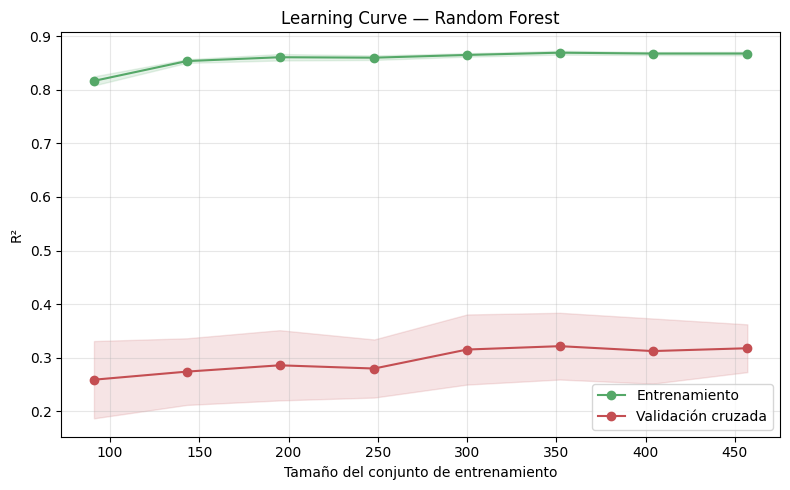

In [32]:
# ── Learning Curve (Random Forest) ───────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Entrenamiento", color="#55A868")
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#55A868")
plt.plot(train_sizes, val_scores.mean(axis=1),   "o-", label="Validación cruzada", color="#C44E52")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#C44E52")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R²")
plt.title("Learning Curve — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Importancia de variables (Random Forest)

Top 10 variables por importancia (Gini):

| Variable | Importancia |
|---|---|
| Depression | 0.3115 |
| OCD | 0.0950 |
| Insomnia | 0.0676 |
| Age | 0.0654 |
| Hours_per_day | 0.0332 |
| genre_diversity | 0.0261 |
| Frequency_Lofi | 0.0253 |
| Frequency_Metal | 0.0203 |
| Frequency_Folk | 0.0196 |
| avg_music_freq | 0.0192 |

**Interpretación con base en el dominio:**

La variable más predictiva es **Depression** (0.31), lo que tiene coherencia clínica directa: la ansiedad y la depresión son comorbilidades frecuentes; el modelo captura esa relación real. OCD e Insomnia son el segundo y tercer predictor, siguiendo el mismo patrón de comorbilidad.

Entre las variables musicales, el feature engineered **genre_diversity** (0.026) aparece antes que cualquier frecuencia individual, lo que valida la decisión de crearlo: la amplitud de géneros escuchados es más predictiva que la frecuencia de un solo género. **Frequency_Lofi** (0.025) aparece antes que Rock o Pop, lo que es coherente con el dominio: Lofi se asocia a personas que buscan calmar la ansiedad o estudiar bajo estrés, reflejando un estado ansioso basal alto.

**Las variables musicales aportan señal secundaria pero real**: `Hours_per_day`, `genre_diversity`, y tres frecuencias de género suman ~12% de la importancia total. Esto confirma que el consumo musical tiene una asociación con la ansiedad, aunque más débil que las comorbilidades directas.

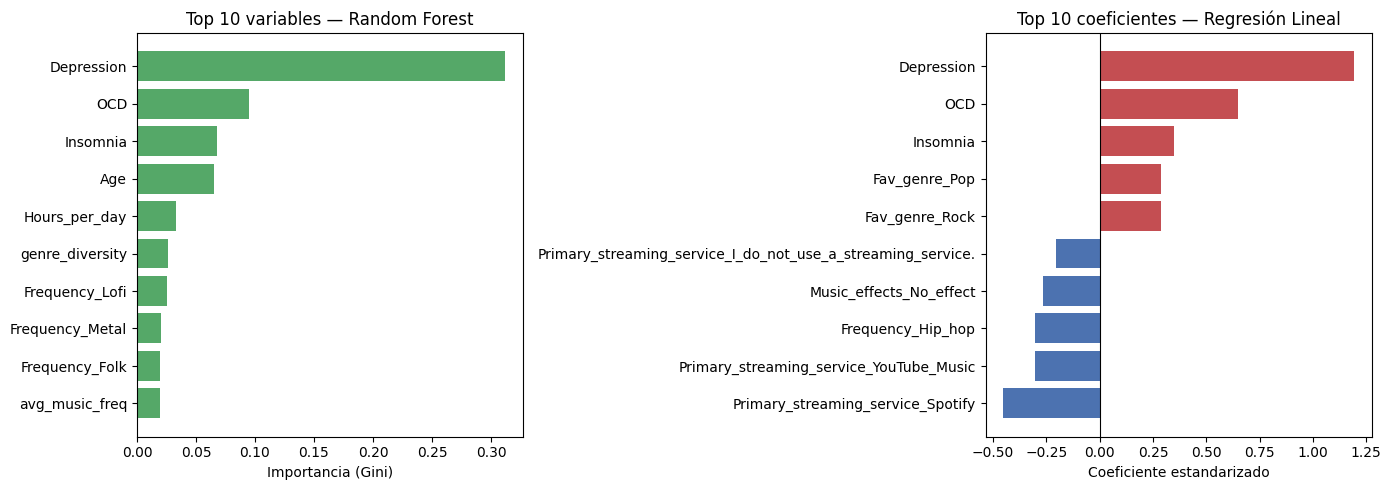


Top 10 variables por importancia (Random Forest):
        Feature  Importance
     Depression    0.311489
            OCD    0.095007
       Insomnia    0.067561
            Age    0.065354
  Hours_per_day    0.033224
genre_diversity    0.026076
 Frequency_Lofi    0.025308
Frequency_Metal    0.020267
 Frequency_Folk    0.019552
 avg_music_freq    0.019205


In [33]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
importances = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top10 = feature_importance.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF importance
axes[0].barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#55A868")
axes[0].set_xlabel("Importancia (Gini)")
axes[0].set_title("Top 10 variables — Random Forest")

# LR coefficients (standardized)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coef": model_lr.coef_
}).reindex(pd.Series(np.abs(model_lr.coef_)).nlargest(10).index)

coef_df = coef_df.sort_values("Coef")
colors_coef = ["#C44E52" if c > 0 else "#4C72B0" for c in coef_df["Coef"]]
axes[1].barh(coef_df["Feature"], coef_df["Coef"], color=colors_coef)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Coeficiente estandarizado")
axes[1].set_title("Top 10 coeficientes — Regresión Lineal")

plt.tight_layout()
plt.show()

print("\nTop 10 variables por importancia (Random Forest):")
print(feature_importance.head(10).to_string(index=False))

## Interpretación de resultados

**Modelo ganador: Random Forest** — RMSE 2.26, R² 0.34, MAPE 42.6%, obtenido con `max_depth=20`, `min_samples_split=5`, `n_estimators=100`.

Random Forest superó a Regresión Lineal (R² 0.30) y XGBoost (R² 0.31) en el conjunto de prueba. La brecha entre los tres modelos es pequeña (~0.04 en R²), lo que sugiere que el techo de predicción con estas variables está cerca del 34% de varianza explicada — el resto es ruido inherente a datos auto-reportados.

**¿Por qué XGBoost no superó a Random Forest aquí?** Con solo ~572 muestras de entrenamiento, el boosting secuencial tiene menos margen para mejorar iterativamente que el bagging de RF. La mejor configuración de XGBoost fue precisamente la más conservadora (`learning_rate=0.05`, `max_depth=3`), lo que indica que el modelo prefirió simplicidad ante el riesgo de sobreajuste. Con un dataset 5-10 veces mayor, XGBoost probablemente superaría a RF.

**¿Por qué Regresión Lineal no es suficiente?** Alcanzó R² 0.30 en test, pero su R² train es solo 0.41 — un gap pequeño que indica que no sobreajusta, pero su capacidad es estructuralmente limitada: las relaciones entre hábitos musicales y ansiedad no son puramente lineales.

## Conclusión

El modelo recomendado para producción es **Random Forest** con los hiperparámetros `max_depth=20`, `min_samples_split=5`, `n_estimators=100` (RMSE: 2.26, R²: 0.34, MAPE: 42.6%).

El hallazgo central del proyecto es que **los principales predictores de la ansiedad no son los hábitos musicales, sino otras variables de salud mental** — Depression, OCD e Insomnia acumulan ~47% de la importancia total. Las variables musicales (`genre_diversity`, `Hours_per_day`, frecuencias de Lofi y Metal) aportan un 12% adicional de señal real.

**Limitaciones del modelo:**
- Overfitting severo en Random Forest (R² train 0.87 vs test 0.34): con ~572 muestras de entrenamiento, los árboles memorizan ruido. Regularización más agresiva o más datos reducirían este gap.
- Datos auto-reportados: la escala 0–10 es subjetiva; el MAPE de ~43% refleja en parte esta variabilidad inherente, no solo error del modelo.
- Variables externas ausentes: historial clínico, contexto socioeconómico o eventos de vida serían altamente predictivos.

**¿Qué haríamos con más tiempo o datos?**
- Aumentar el dataset para reducir el gap train/test — la Learning Curve sugiere que la validación aún no converge
- Explorar Ridge/Lasso como alternativas regularizadas a OLS
- Aplicar SHAP values para explicabilidad local del modelo ganador
- Reformular como clasificación binaria (ansiedad ≥ 7 = riesgo alto) para evaluar si mejora la utilidad práctica

Este proyecto demuestra que los hábitos musicales tienen una asociación real pero secundaria con la ansiedad. Un modelo de alerta temprana basado en estos datos debería combinarse con otras variables clínicas para ser útil en la práctica.